**Лабораторная работа №1**. Выявление характеристических признаков сигнала.

Цель работы - получить теоретические и практические навыки работы со звуковым сигналом.

1.1. Сгенерировать сэмпл белого или розового шума длительностью до 30 секунд (нечетная подгруппа - белый, чётная - розовый).\
1.2. Взять фильтр номер Х, где Х - номера подгруппы, и фильтр Y, где Y = остаток от деления (X+8) на 13.\
1.3. Определить и показать характеристики сигнала (как минимум, АЧХ) + спектрограмма по времени.\
1.4. Применить отдельно каждый фильтр.\
1.5. Показать спектрограмму по времени.

2.1. Взять 3 фрагмента сигнала: речь (монолог), чистая инструментальная музыка, интересный звуковой сэмпл до 30 секунд каждый.\
2.2. Определить и показать характеристики сигнала (как минимум, АЧХ) + спектрограмма по времени.\
2.3. Применить отдельно каждый фильтр.\
2.4. Показать спектрограмму по времени.\
2.5. Применить все фильтры последовательно.\
2.6. Показать спектрограмму по времени.

# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Часть 1

## Генерация розового шума

Розовый шум имеет спектральную плотность:

$$
P(f) ~ \frac{1}{f}
$$

То есть мощность уменьшается с ростом частоты.

In [ ]:
fs = 44100        # частота дискретизации
duration = 10     # длительность сигнала
N = fs*duration

# генерация белого шума
white = np.random.randn(N)

# коэффициенты цифрового фильтра - аппроксимация фильтра 1/f, предложенная Paul Kellet
b = [0.049922035, -0.095993537, 0.050612699, -0.004408786]
a = [1, -2.494956002, 2.017265875, -0.522189400]

# генерация розового шума
pink = signal.lfilter(b, a, white)

## Характеристики сигнала

АЧХ (спектр)

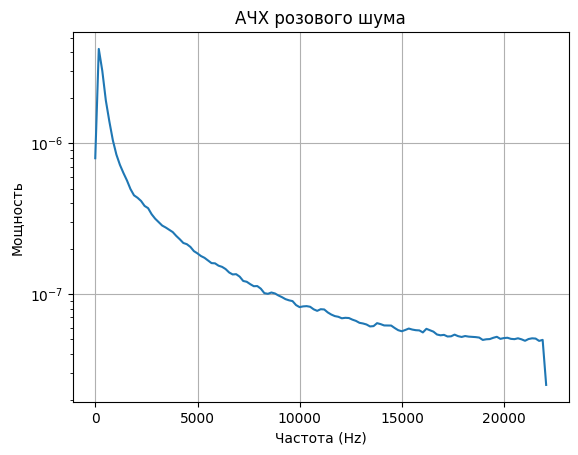

In [3]:
freqs, psd = signal.welch(pink, fs)

plt.figure()
plt.semilogy(freqs, psd)
plt.title("АЧХ розового шума")
plt.xlabel("Частота (Hz)")
plt.ylabel("Мощность")
plt.grid()
plt.show()

Спектрограмма по времени

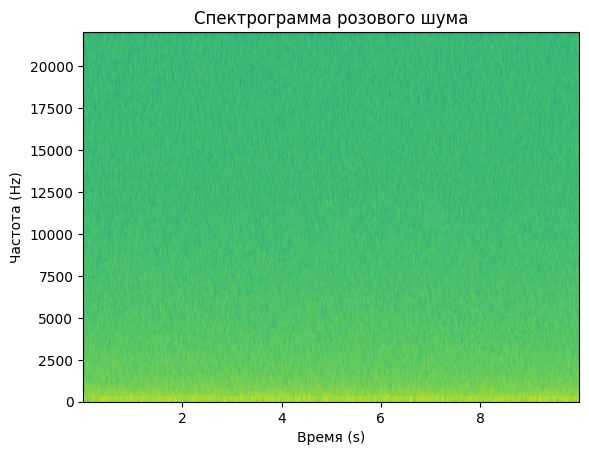

In [4]:
plt.figure()
plt.specgram(pink, Fs=fs)
plt.title("Спектрограмма розового шума")
plt.xlabel("Время (s)")
plt.ylabel("Частота (Hz)")
plt.show()

## Фильтр Бесселя

Фильтр Бесселя известен тем, что минимально искажает фазу сигнала.

In [5]:
b_bessel, a_bessel = signal.bessel(4, 0.2, btype='low', analog=False)

pink_bessel = signal.lfilter(b_bessel, a_bessel, pink)

Спектрограмма после фильтра Бесселя

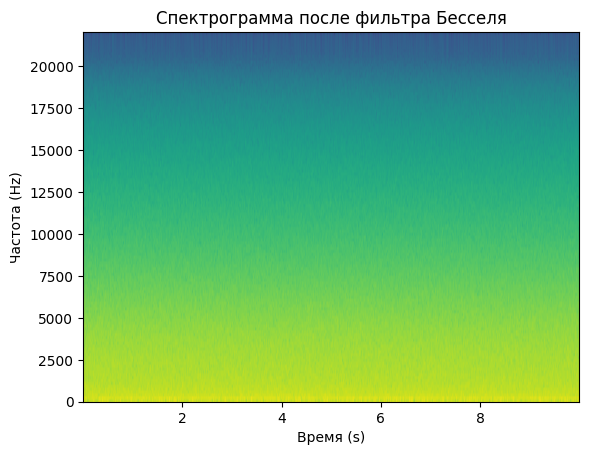

In [6]:
plt.figure()
plt.specgram(pink_bessel, Fs=fs)
plt.title("Спектрограмма после фильтра Бесселя")
plt.xlabel("Время (s)")
plt.ylabel("Частота (Hz)")
plt.show()

## Фильтр Баттерворта

Фильтр Баттерворта имеет максимально ровную АЧХ в полосе пропускания.

In [7]:
b_butter, a_butter = signal.butter(4, 0.2, btype='low')

pink_butter = signal.lfilter(b_butter, a_butter, pink)

Спектрограмма после фильтра Баттерворта

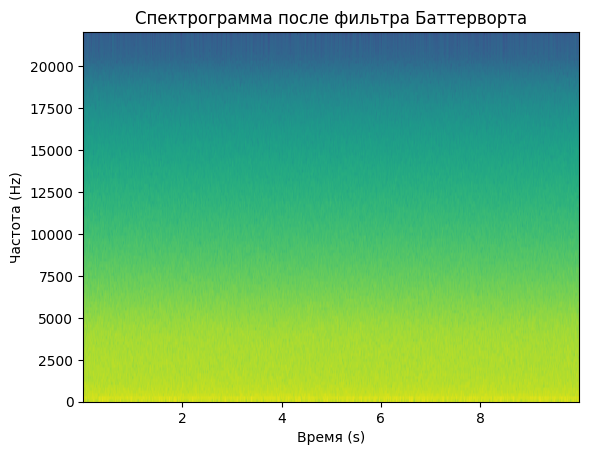

In [8]:
plt.figure()
plt.specgram(pink_butter, Fs=fs)
plt.title("Спектрограмма после фильтра Баттерворта")
plt.xlabel("Время (s)")
plt.ylabel("Частота (Hz)")
plt.show()

# Часть 2